In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "ACSST1Y2024.S1902-2026-05-08T012308.csv"

df = pd.read_csv(file_path)

df.head(20)

,Label (Grouping),Massachusetts!!Number!!Estimate,Massachusetts!!Number!!Margin of Error,Massachusetts!!Percent Distribution!!Estimate,Massachusetts!!Percent Distribution!!Margin of Error,Massachusetts!!Mean income (dollars)!!Estimate,Massachusetts!!Mean income (dollars)!!Margin of Error,"Boston city, Massachusetts!!Number!!Estimate","Boston city, Massachusetts!!Number!!Margin of Error","Boston city, Massachusetts!!Percent Distribution!!Estimate","Boston city, Massachusetts!!Percent Distribution!!Margin of Error","Boston city, Massachusetts!!Mean income (dollars)!!Estimate","Boston city, Massachusetts!!Mean income (dollars)!!Margin of Error"
0,HOUSEHOLD INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All households,"2,829,804","9,140","2,829,804","9,140","144,312","1,304","294,977","3,333","294,977","3,333","138,724","5,206"
2,With earnings,"2,226,456","11,252",78.70%,0.3,"149,436","1,513","238,679","5,436",80.90%,1.4,"147,632","4,750"
3,With wages or salary income,"2,160,543","12,511",76.30%,0.4,"146,494","1,441","234,329","5,448",79.40%,1.5,"145,324","4,915"
4,With self-employment income,"310,653","9,386",11.00%,0.3,"52,170","3,270","27,637","2,832",9.40%,1,"42,809","12,737"
5,"With interest, dividends, or net renta...","725,865","13,198",25.70%,0.5,"32,557","2,251","71,037","4,722",24.10%,1.5,"36,528","10,365"
6,With Social Security income,"872,672","10,854",30.80%,0.4,"25,232",325,"63,049","3,320",21.40%,1.1,"21,709","1,387"
7,With Supplemental Security Income (SSI),"151,041","6,430",5.30%,0.2,"10,918",348,"20,624","3,177",7.00%,1.1,"10,561",768
8,With cash public assistance income or ...,"454,353","10,564",16.10%,0.4,(X),(X),"65,125","3,882",22.10%,1.3,(X),(X)
9,With cash public assistance,"95,822","5,743",3.40%,0.2,"4,294",300,"12,078","2,060",4.10%,0.7,"4,057",761


In [2]:
for col in df.columns:
    print(col)

Label (Grouping)
Massachusetts!!Number!!Estimate
Massachusetts!!Number!!Margin of Error
Massachusetts!!Percent Distribution!!Estimate
Massachusetts!!Percent Distribution!!Margin of Error
Massachusetts!!Mean income (dollars)!!Estimate
Massachusetts!!Mean income (dollars)!!Margin of Error
Boston city, Massachusetts!!Number!!Estimate
Boston city, Massachusetts!!Number!!Margin of Error
Boston city, Massachusetts!!Percent Distribution!!Estimate
Boston city, Massachusetts!!Percent Distribution!!Margin of Error
Boston city, Massachusetts!!Mean income (dollars)!!Estimate
Boston city, Massachusetts!!Mean income (dollars)!!Margin of Error


In [40]:
df["race"] = (
    df["race"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
)

df[[
    "race",
    "number",
    "number_moe",
    "percent_distribution",
    "percent_distribution_moe",
    "mean_income",
    "mean_income_moe"
]].head(20)

,race,number,number_moe,percent_distribution,percent_distribution_moe,mean_income,mean_income_moe
0,HOUSEHOLD INCOME,NaN,NaN,NaN,NaN,NaN,NaN
1,All households,"294,977","3,333","294,977","3,333","138,724","5,206"
2,With earnings,"238,679","5,436",80.90%,1.4,"147,632","4,750"
3,With wages or salary income,"234,329","5,448",79.40%,1.5,"145,324","4,915"
4,With self-employment income,"27,637","2,832",9.40%,1,"42,809","12,737"
5,"With interest, dividends, or net rental income","71,037","4,722",24.10%,1.5,"36,528","10,365"
6,With Social Security income,"63,049","3,320",21.40%,1.1,"21,709","1,387"
7,With Supplemental Security Income (SSI),"20,624","3,177",7.00%,1.1,"10,561",768
8,With cash public assistance income or Food Sta...,"65,125","3,882",22.10%,1.3,(X),(X)
9,With cash public assistance,"12,078","2,060",4.10%,0.7,"4,057",761


In [41]:
df["race"] = df["race"].astype(str).str.strip()

df[["race", "number", "mean_income"]].head(20)

,race,number,mean_income
0,HOUSEHOLD INCOME,NaN,NaN
1,All households,"294,977","138,724"
2,With earnings,"238,679","147,632"
3,With wages or salary income,"234,329","145,324"
4,With self-employment income,"27,637","42,809"
5,"With interest, dividends, or net rental income","71,037","36,528"
6,With Social Security income,"63,049","21,709"
7,With Supplemental Security Income (SSI),"20,624","10,561"
8,With cash public assistance income or Food Sta...,"65,125",(X)
9,With cash public assistance,"12,078","4,057"


In [42]:
# Find the row index where each section starts
one_race_start = df[df["race"].str.lower() == "one race"].index[0]
two_race_start = df[df["race"].str.lower() == "two or more races"].index[0]

# One race section = after "One race" until before "Two or more races"
one_race_df = df.loc[one_race_start + 1 : two_race_start - 1].copy()

# Two or more races section = after "Two or more races"
two_or_more_df = df.loc[two_race_start + 1 :].copy()

# Combine them
race_income = pd.concat([one_race_df, two_or_more_df], ignore_index=True)

race_income.head()

,race,Massachusetts!!Number!!Estimate,Massachusetts!!Number!!Margin of Error,Massachusetts!!Percent Distribution!!Estimate,Massachusetts!!Percent Distribution!!Margin of Error,Massachusetts!!Mean income (dollars)!!Estimate,Massachusetts!!Mean income (dollars)!!Margin of Error,number,number_moe,percent_distribution,percent_distribution_moe,mean_income,mean_income_moe
0,White,"4,761,129","19,095",66.70%,0.3,"65,979",687,"310,697","6,099",46.10%,0.9,"87,062","3,816"
1,Black or African American,"489,490","13,494",6.90%,0.2,"36,888","1,518","131,495","7,270",19.50%,1.1,"32,877","2,912"
2,American Indian and Alaska Native,"17,332","4,054",0.20%,0.1,"32,406","7,663","2,603","1,114",0.40%,0.2,"34,728","10,944"
3,Asian,"551,579","6,516",7.70%,0.1,"65,775","2,526","72,846","3,171",10.80%,0.5,"56,452","8,804"
4,Native Hawaiian and Other Pacific Islander,"1,265",458,0.00%,0.1,"48,410","31,863",106,144,0.00%,0.1,N,N


In [46]:
race_income = race_income[[
    "race",
    "number",
    "number_moe",
    "percent_distribution",
    "percent_distribution_moe",
    "mean_income",
    "mean_income_moe"
]].copy()

In [47]:
race_rows = [
    "Total population",
    "White",
    "Black or African American",
    "American Indian and Alaska Native",
    "Asian",
    "Native Hawaiian and Other Pacific Islander",
    "Some other race",
    "Two or more races",
    "Hispanic or Latino origin (of any race)",
    "White alone, not Hispanic or Latino"
]

race_income = df[df["race"].isin(race_rows)].copy()

race_income = race_income[[
    "race",
    "number",
    "number_moe",
    "percent_distribution",
    "percent_distribution_moe",
    "mean_income",
    "mean_income_moe"
]]

race_income

,race,number,number_moe,percent_distribution,percent_distribution_moe,mean_income,mean_income_moe
21,Total population,"673,822","3,086","673,822","3,086","60,885","2,082"
23,White,"310,697","6,099",46.10%,0.9,"87,062","3,816"
24,Black or African American,"131,495","7,270",19.50%,1.1,"32,877","2,912"
25,American Indian and Alaska Native,"2,603","1,114",0.40%,0.2,"34,728","10,944"
26,Asian,"72,846","3,171",10.80%,0.5,"56,452","8,804"
27,Native Hawaiian and Other Pacific Islander,106,144,0.00%,0.1,N,N
28,Some other race,"42,569","6,118",6.30%,0.9,"28,618","4,159"
29,Two or more races,"113,506","10,064",16.80%,1.5,"37,266","3,514"
30,Hispanic or Latino origin (of any race),"139,222","4,915",20.70%,0.7,"31,632","2,301"
31,"White alone, not Hispanic or Latino","297,111","5,113",44.10%,0.7,"89,252","3,862"


In [48]:
cols = [
    "number",
    "number_moe",
    "percent_distribution",
    "percent_distribution_moe",
    "mean_income",
    "mean_income_moe"
]

for col in cols:
    race_income[col] = (
        race_income[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("(X)", "", regex=False)
        .str.replace("N", "", regex=False)
        .str.strip()
    )

    race_income[col] = pd.to_numeric(race_income[col], errors="coerce")

race_income

,race,number,number_moe,percent_distribution,percent_distribution_moe,mean_income,mean_income_moe
21,Total population,673822,3086,673822.0,3086.0,60885.0,2082.0
23,White,310697,6099,46.1,0.9,87062.0,3816.0
24,Black or African American,131495,7270,19.5,1.1,32877.0,2912.0
25,American Indian and Alaska Native,2603,1114,0.4,0.2,34728.0,10944.0
26,Asian,72846,3171,10.8,0.5,56452.0,8804.0
27,Native Hawaiian and Other Pacific Islander,106,144,0.0,0.1,NaN,NaN
28,Some other race,42569,6118,6.3,0.9,28618.0,4159.0
29,Two or more races,113506,10064,16.8,1.5,37266.0,3514.0
30,Hispanic or Latino origin (of any race),139222,4915,20.7,0.7,31632.0,2301.0
31,"White alone, not Hispanic or Latino",297111,5113,44.1,0.7,89252.0,3862.0


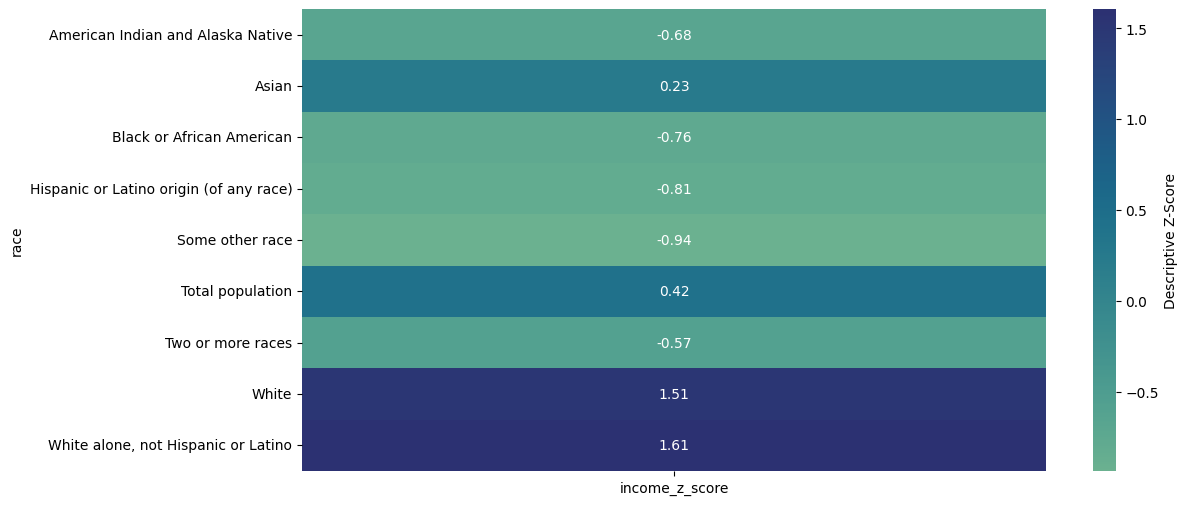

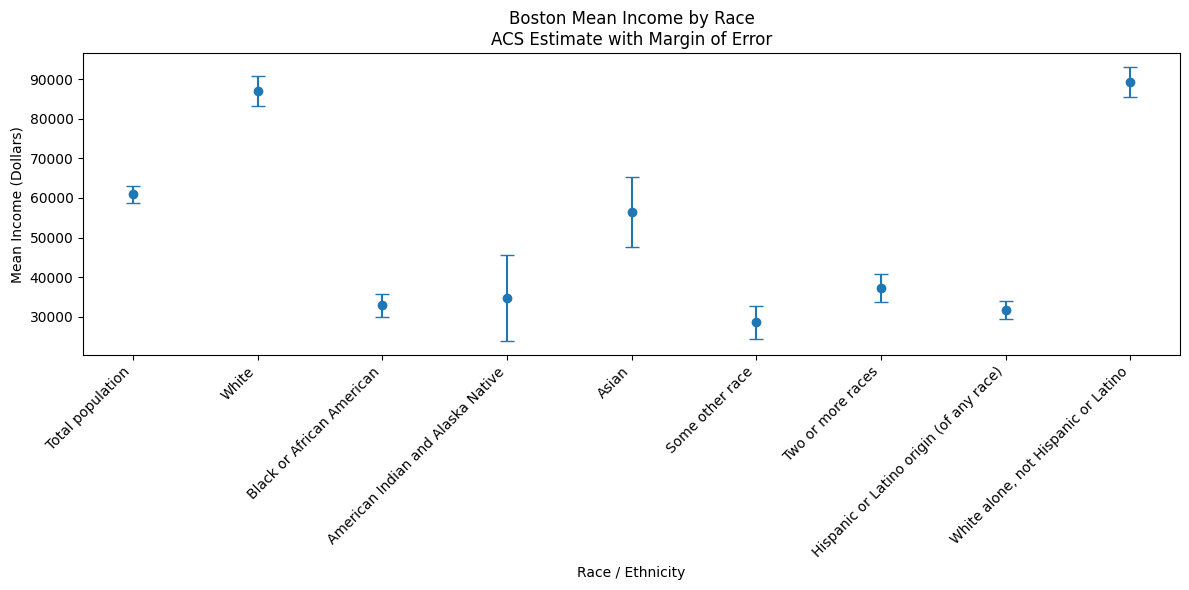

In [64]:
# Descriptive z-score for visualization
race_income["income_z_score"] = (
    race_income["mean_income"] - race_income["mean_income"].mean()
) / race_income["mean_income"].std()

plt.figure(figsize=(12, 6))

sns.heatmap(
    race_income.pivot_table(
        values="income_z_score",
        index="race"
    ),
    annot=True,
    cmap="crest",
    center=0,
    fmt=".2f",
    cbar_kws={"label": "Descriptive Z-Score"}
)

# Remove rows where income or MOE is missing
income_data = race_income.dropna(
    subset=["mean_income", "mean_income_moe"]
).copy()

# Create the error bar plot
plt.figure(figsize=(12, 6))

plt.errorbar(
    x=income_data["race"],
    y=income_data["mean_income"],
    yerr=income_data["mean_income_moe"],
    fmt="o",
    capsize=5
)

# Customize the plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Race / Ethnicity")
plt.ylabel("Mean Income (Dollars)")
plt.title("Boston Mean Income by Race\nACS Estimate with Margin of Error")
plt.tight_layout()
plt.show()

